# Atividade Prática 1 - Grupo 3


## Questões em Grupo

## 0. Importações e Funções Auxiliares

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.signal import find_peaks, butter, filtfilt
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

# Configurações de plot
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Carregamento dos Dados

Os arquivos de dados contêm as coordenadas (x, y) dos marcadores:
- **A** = Acrômio
- **T** = Trocânter
- **E** = Epicôndilo lateral do fêmur
- **M** = Maléolo lateral
- **C** = Calcâneo
- **5Mt** = 5º Metatarso

Arquivos disponíveis (velocidades diferentes):
- `bel_4_dados.txt` → velocidade 4
- `bel_5_dados.txt` → velocidade 5
- `bel_6_dados.txt` → velocidade 6

In [32]:
def load_data(filepath):
    rows = []
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.strip()
            # Pula linhas de cabeçalho
            if line.startswith('#') or line.startswith(';') or line.startswith('t') or line == '':
                continue
            # Substitui vírgula decimal por ponto (mas não vírgulas de separação)
            # O separador de campos é ponto-e-vírgula
            parts = line.split(';')
            if len(parts) < 13:
                continue
            try:
                # Converte cada campo: troca vírgula decimal por ponto
                vals = [float(p.strip().replace(',', '.')) for p in parts[:13]]
                rows.append(vals)
            except ValueError:
                continue

    cols = ['t',
            'Ax', 'Ay',   # Acrômio
            'Tx', 'Ty',   # Trocânter
            'Ex', 'Ey',   # Epicôndilo
            'Mx', 'My',   # Maléolo
            'Cx', 'Cy',   # Calcâneo
            'MTx', 'MTy'] # 5º Metatarso

    df = pd.DataFrame(rows, columns=cols)
    return df


file_v4 = 'bel_4_dados.txt'
file_v5 = 'bel_5_dados.txt'
file_v6 = 'bel_6_dados.txt'

df4 = load_data(file_v4)
df5 = load_data(file_v5)
df6 = load_data(file_v6)

velocidades = {'v4': df4, 'v5': df5, 'v6': df6}
labels_vel  = {'v4': 'Velocidade 4', 'v5': 'Velocidade 5', 'v6': 'Velocidade 6'}
cores_vel   = {'v4': '#1f77b4', 'v5': '#ff7f0e', 'v6': '#2ca02c'}

print("Dados carregados com sucesso!")
for k, df in velocidades.items():
    print(f"  {labels_vel[k]}: {len(df)} amostras | t = [{df['t'].min():.3f} s, {df['t'].max():.3f} s]")

Dados carregados com sucesso!
  Velocidade 4: 541 amostras | t = [0.000 s, 9.003 s]
  Velocidade 5: 829 amostras | t = [0.000 s, 13.806 s]
  Velocidade 6: 1084 amostras | t = [0.000 s, 18.057 s]


---
## Questão 1 – Identificação do Toque do Pé e do Toe-off

### Algoritmo

Para identificar o **toque do pé no chão (heel strike)** e o **toe-off**, utilizamos a posição vertical (y) do calcâneo e do 5º metatarso:

1. **Heel Strike**: mínimo local da coordenada vertical do calcâneo (`Cy`). Quando o calcanhar toca o chão, sua posição vertical atinge um mínimo.
2. **Toe-off**: mínimo local da coordenada vertical do 5º metatarso (`MTy`). Quando os dedos deixam o chão, o metatarso também atinge um mínimo local.

Um filtro Butterworth passa-baixa é aplicado antes da detecção de picos para remover ruído de alta frequência.

In [33]:
def butter_lowpass(data, cutoff=6, fs=60, order=4):
    """Filtro Butterworth passa-baixa."""
    nyq = fs / 2
    b, a = butter(order, cutoff / nyq, btype='low')
    return filtfilt(b, a, data)


def detect_events(df, min_distance_s=0.3):

    t = df['t'].values
    dt = np.mean(np.diff(t))
    fs = 1 / dt
    min_dist_samples = int(min_distance_s / dt)

    # Filtra sinais
    cy_filt  = butter_lowpass(df['Cy'].values,  cutoff=6, fs=fs)
    mty_filt = butter_lowpass(df['MTy'].values, cutoff=6, fs=fs)

    # Heel strike = mínimos do calcâneo
    hs_idx, _ = find_peaks(-cy_filt, distance=min_dist_samples, prominence=0.005)
    hs_times  = t[hs_idx]

    # Toe-off = mínimos do metatarso
    to_idx, _ = find_peaks(-mty_filt, distance=min_dist_samples, prominence=0.005)
    to_times  = t[to_idx]

    return hs_times, to_times, cy_filt, mty_filt


# Detecta eventos para cada velocidade
eventos = {}
for key, df in velocidades.items():
    hs, to, cy_f, mty_f = detect_events(df)
    eventos[key] = {'hs': hs, 'to': to, 'cy_filt': cy_f, 'mty_filt': mty_f}
    print(f"\n{labels_vel[key]}")
    print(f"  Heel strikes detectados: {hs}")
    print(f"  Toe-offs detectados:     {to}")


Velocidade 4
  Heel strikes detectados: [0.884 2.034 3.151 4.335 5.419 6.569 7.686 8.787]
  Toe-offs detectados:     [0.667 1.017 1.801 2.384 2.951 3.551 4.085 4.702 5.252 5.719 6.352 6.686
 7.47  8.02  8.603]

Velocidade 5
  Heel strikes detectados: [ 0.167  1.217  2.218  3.201  4.235  5.319  6.319  7.353  8.387  9.404
 10.454 11.538 12.522 13.572]
  Toe-offs detectados:     [ 0.5    1.     1.551  1.984  2.318  3.001  3.418  4.018  4.602  5.069
  5.369  6.103  6.403  7.153  7.47   8.153  8.47   9.204  9.537 10.254
 10.554 11.305 11.805 12.355 12.655 13.356]

Velocidade 6
  Heel strikes detectados: [ 0.984  1.951  2.918  3.902  4.835  5.702  6.669  7.736  8.637  9.72
 10.654 11.588 12.588 13.539 14.539 15.523 16.373 17.323]
  Toe-offs detectados:     [ 0.1    0.467  0.784  1.067  1.417  1.734  2.034  2.418  2.734  3.035
  3.701  3.985  4.652  4.952  5.602  5.919  6.569  6.886  7.57   7.853
  8.82   9.487  9.954 10.738 11.671 12.355 12.638 13.339 13.622 14.306
 14.622 15.573 16.256 16.

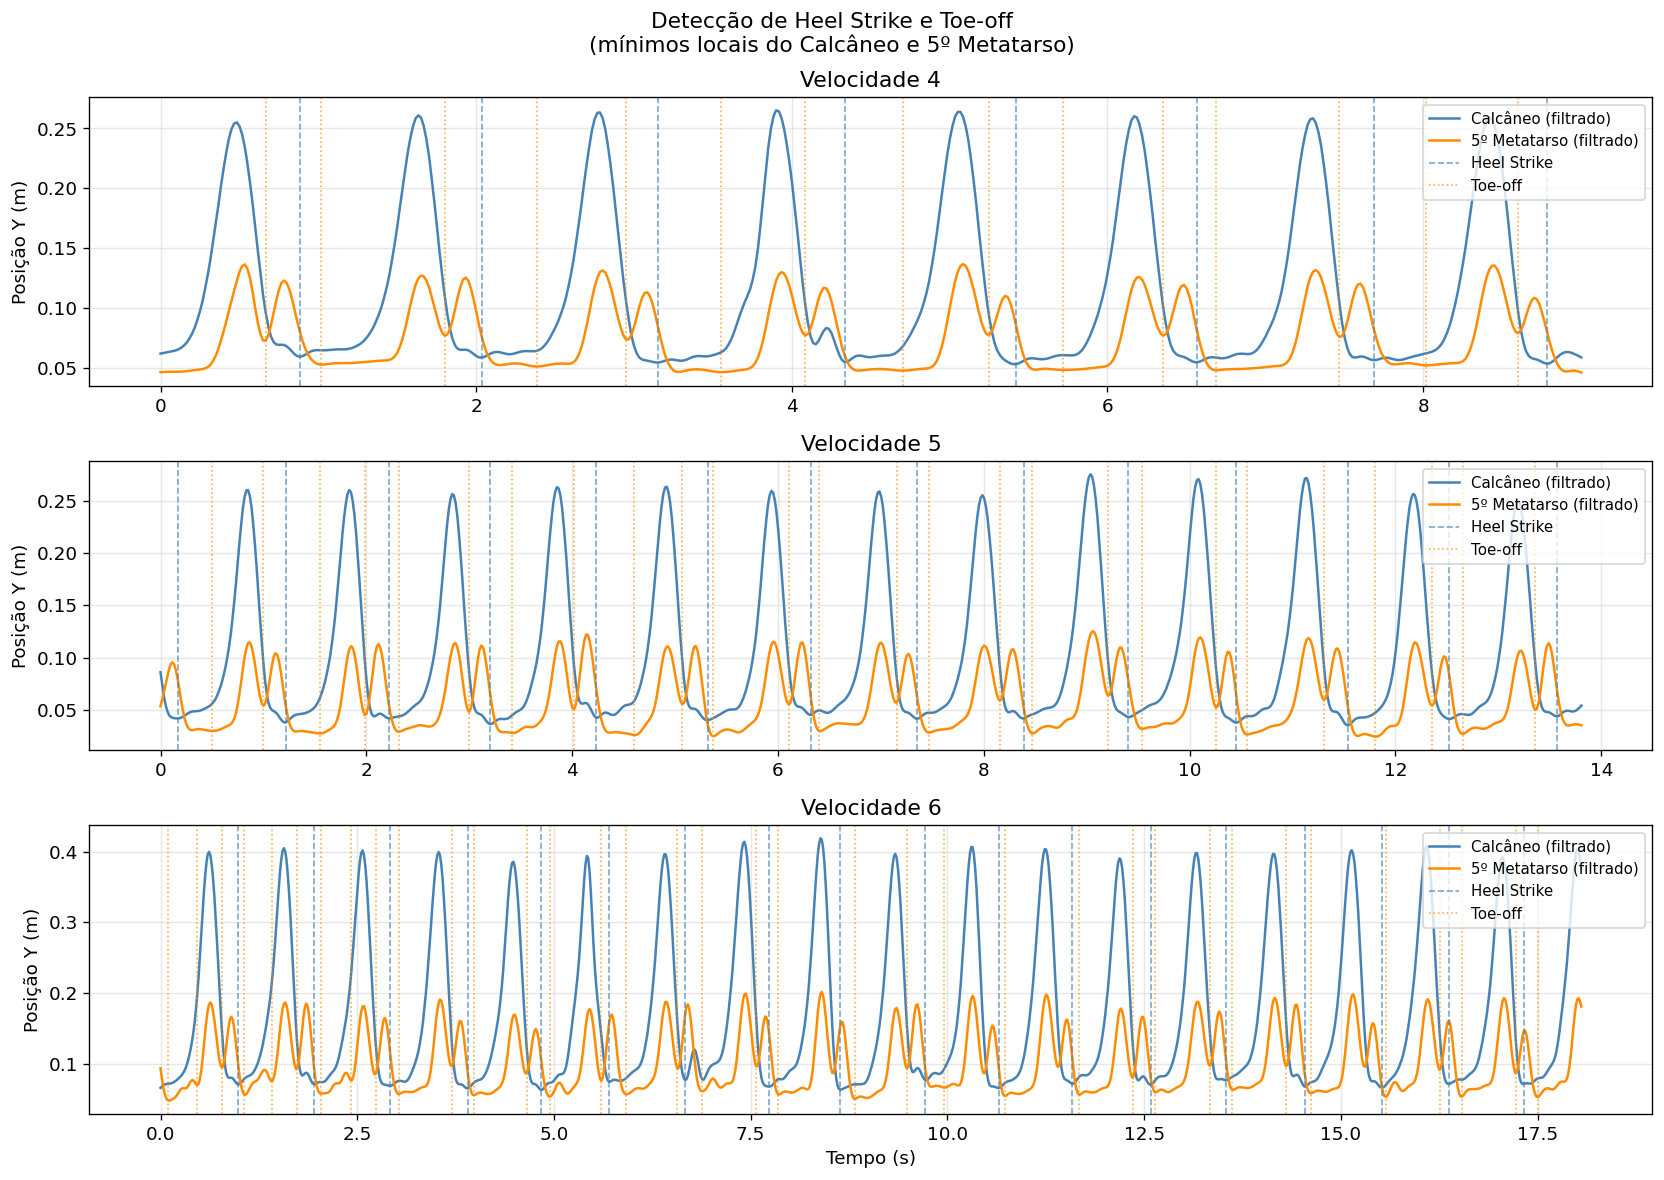

In [34]:
# Visualização da detecção de eventos
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, (key, df) in zip(axes, velocidades.items()):
    t = df['t'].values
    ev = eventos[key]

    ax.plot(t, ev['cy_filt'],  label='Calcâneo (filtrado)',   color='steelblue', lw=1.5)
    ax.plot(t, ev['mty_filt'], label='5º Metatarso (filtrado)', color='darkorange', lw=1.5)

    # Marca eventos
    for hs in ev['hs']:
        ax.axvline(hs, color='steelblue', linestyle='--', alpha=0.7, lw=1)
    for to in ev['to']:
        ax.axvline(to, color='darkorange', linestyle=':', alpha=0.7, lw=1)

    # Legenda custom
    ax.axvline(np.nan, color='steelblue', linestyle='--', alpha=0.7, lw=1, label='Heel Strike')
    ax.axvline(np.nan, color='darkorange', linestyle=':', alpha=0.7, lw=1, label='Toe-off')

    ax.set_ylabel('Posição Y (m)')
    ax.set_title(labels_vel[key])
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Tempo (s)')
plt.suptitle('Detecção de Heel Strike e Toe-off\n(mínimos locais do Calcâneo e 5º Metatarso)', fontsize=13)
plt.tight_layout()
plt.show()

In [35]:
# ---------------------------------------------------------------
# Questão 1a – Tabela de instantes detectados
# Questão 1b – Duração da passada e fase de apoio
# ---------------------------------------------------------------

# Para cada velocidade, seleciona 3 passadas (3 pares consecutivos de heel strikes)
NUM_PASSADAS = 3

resultados_q1 = []

for key, df in velocidades.items():
    ev = eventos[key]
    hs = ev['hs']
    to = ev['to']

    for i in range(min(NUM_PASSADAS, len(hs) - 1)):
        t_hs1 = hs[i]          # Início da passada
        t_hs2 = hs[i + 1]      # Fim da passada (próximo heel strike)
        duracao_passada = t_hs2 - t_hs1

        # Toe-off dentro desta passada
        to_passada = to[(to > t_hs1) & (to < t_hs2)]
        if len(to_passada) == 0:
            continue
        t_to = to_passada[0]

        duracao_apoio = t_to - t_hs1
        pct_apoio = (duracao_apoio / duracao_passada) * 100

        resultados_q1.append({
            'Velocidade':          labels_vel[key],
            'Passada':             i + 1,
            'Heel Strike (s)':     round(t_hs1, 4),
            'Toe-off (s)':         round(t_to, 4),
            'Próx. HS (s)':        round(t_hs2, 4),
            'Duração Passada (s)': round(duracao_passada, 4),
            'Dur. Apoio (s)':      round(duracao_apoio, 4),
            'Apoio (%passada)':    round(pct_apoio, 2)
        })

df_q1 = pd.DataFrame(resultados_q1)
print("\n=== Questão 1a – Instantes dos Eventos Detectados ===")
print(df_q1.to_string(index=False))


=== Questão 1a – Instantes dos Eventos Detectados ===
  Velocidade  Passada  Heel Strike (s)  Toe-off (s)  Próx. HS (s)  Duração Passada (s)  Dur. Apoio (s)  Apoio (%passada)
Velocidade 4        1            0.884        1.017         2.034                1.150           0.133             11.57
Velocidade 4        2            2.034        2.384         3.151                1.117           0.350             31.33
Velocidade 4        3            3.151        3.551         4.335                1.184           0.400             33.78
Velocidade 5        1            0.167        0.500         1.217                1.050           0.333             31.71
Velocidade 5        2            1.217        1.551         2.218                1.001           0.334             33.37
Velocidade 5        3            2.218        2.318         3.201                0.983           0.100             10.17
Velocidade 6        1            0.984        1.067         1.951                0.967           0

In [36]:
# Questão 1b – Média e erro padrão por velocidade
print("\n=== Questão 1b – Média e Erro Padrão ===")
resumo_q1 = df_q1.groupby('Velocidade').agg(
    Dur_Passada_Media=('Duração Passada (s)', 'mean'),
    Dur_Passada_EP=('Duração Passada (s)', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
    Dur_Apoio_Media=('Dur. Apoio (s)', 'mean'),
    Dur_Apoio_EP=('Dur. Apoio (s)', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
    Pct_Apoio_Media=('Apoio (%passada)', 'mean'),
    Pct_Apoio_EP=('Apoio (%passada)', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
).reset_index()

resumo_q1 = resumo_q1.round(4)
print(resumo_q1.to_string(index=False))


=== Questão 1b – Média e Erro Padrão ===
  Velocidade  Dur_Passada_Media  Dur_Passada_EP  Dur_Apoio_Media  Dur_Apoio_EP  Pct_Apoio_Media  Pct_Apoio_EP
Velocidade 4             1.1503          0.0193           0.2943        0.0819          25.5600        7.0307
Velocidade 5             1.0113          0.0200           0.2557        0.0778          25.0833        7.4720
Velocidade 6             0.9727          0.0057           0.0943        0.0113           9.6833        1.1033


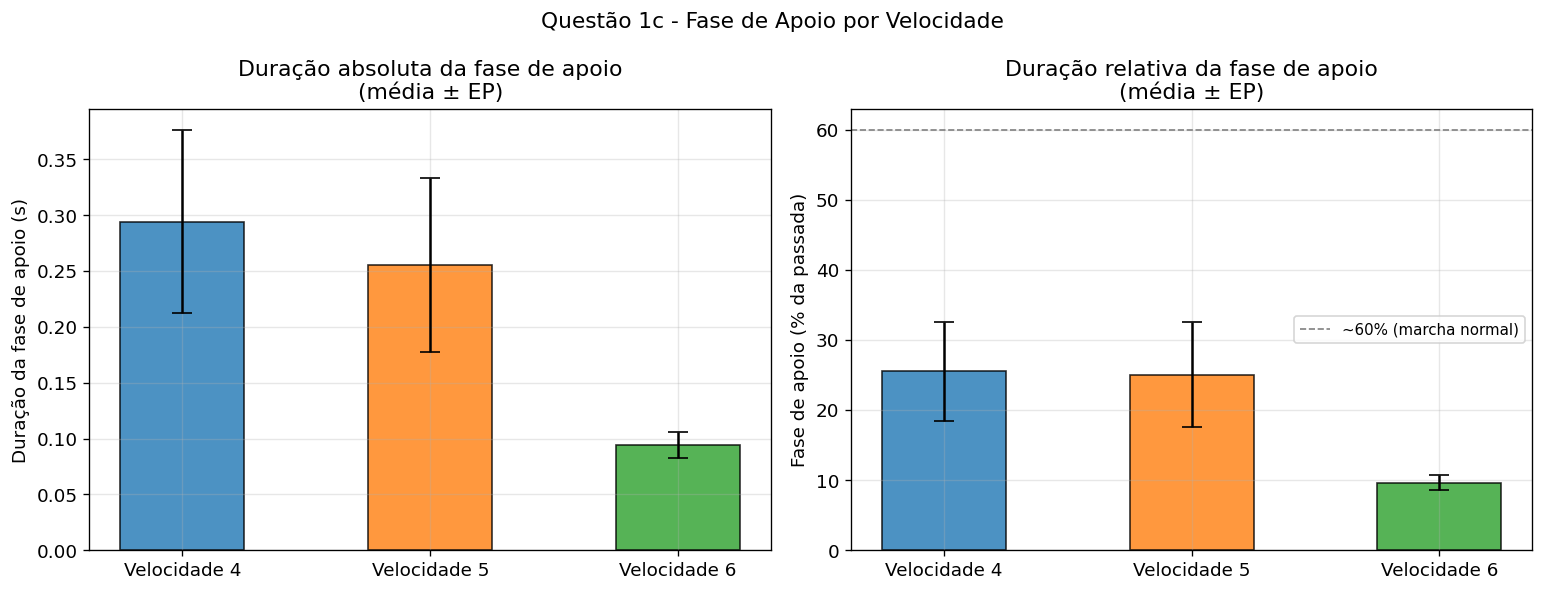


Espera-se que com o aumento da velocidade a fase de apoio diminua em valor absoluto
e que a fase de balanço (e eventual fase de duplo apoio/voo) se altere.
Na corrida, não há fase de duplo apoio; ao aumentar a velocidade, a fase de apoio
tende a representar uma porção cada vez menor do ciclo.



In [37]:
# Questão 1c – Gráfico da duração da fase de apoio por velocidade
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

vel_labels = resumo_q1['Velocidade'].tolist()
x = np.arange(len(vel_labels))
width = 0.5

# Gráfico 1: Duração absoluta (s)
ax = axes[0]
ax.bar(x, resumo_q1['Dur_Apoio_Media'], width,
       yerr=resumo_q1['Dur_Apoio_EP'], capsize=6,
       color=[cores_vel[k] for k in ['v4','v5','v6']], alpha=0.8, edgecolor='k')
ax.set_xticks(x)
ax.set_xticklabels(vel_labels)
ax.set_ylabel('Duração da fase de apoio (s)')
ax.set_title('Duração absoluta da fase de apoio\n(média ± EP)')

# Gráfico 2: Duração relativa (%passada)
ax = axes[1]
ax.bar(x, resumo_q1['Pct_Apoio_Media'], width,
       yerr=resumo_q1['Pct_Apoio_EP'], capsize=6,
       color=[cores_vel[k] for k in ['v4','v5','v6']], alpha=0.8, edgecolor='k')
ax.set_xticks(x)
ax.set_xticklabels(vel_labels)
ax.set_ylabel('Fase de apoio (% da passada)')
ax.set_title('Duração relativa da fase de apoio\n(média ± EP)')
ax.axhline(60, color='gray', linestyle='--', lw=1, label='~60% (marcha normal)')
ax.legend(fontsize=9)

plt.suptitle('Questão 1c - Fase de Apoio por Velocidade', fontsize=13)
plt.tight_layout()
plt.show()

print("""
Espera-se que com o aumento da velocidade a fase de apoio diminua em valor absoluto
e que a fase de balanço (e eventual fase de duplo apoio/voo) se altere.
Na corrida, não há fase de duplo apoio; ao aumentar a velocidade, a fase de apoio
tende a representar uma porção cada vez menor do ciclo.
""")

---
## Questão 2 – Ângulos Articulares e Segmentares ao Longo do Ciclo

### Modelo Antropométrico e Definição dos Ângulos



Os **ângulos articulares** :

| Articulação | Segmento proximal | Segmento distal |
|-------------|------------------|-----------------|
| Quadril     | Tronco (A→T)     | Coxa (T→E)      |
| Joelho      | Coxa (T→E)       | Perna (E→M)     |
| Tornozelo   | Perna (E→M)      | Pé (M→5Mt/C)    |

Convenção: positivo = flexão; negativo = extensão.

In [38]:
def segmental_angle(px, py, dx, dy):
    """
    Calcula o ângulo segmentar em relação ao eixo vertical (posição anatômica).
    Convenção: ângulo positivo = segmento inclinado para frente (flexão).
    """
    # Vetor do proximal para o distal
    vx = px - dx
    vy = py - dy
    # Ângulo em relação ao eixo vertical (y positivo para cima)
    # arctan2(vx, vy): positivo quando vx > 0 (segmento para frente)

    theta_segmentar = np.degrees(np.arctan2(vy, vx))
    
    for i in range(len(theta_segmentar)):
        if theta_segmentar[i] < 0 and vy[i] < 0:
            theta_segmentar[i] = theta_segmentar[i] + 360

    return theta_segmentar


# def joint_angle(theta_proximal, theta_distal):
#     """
#     Ângulo articular = ângulo do segmento distal - ângulo do segmento proximal.
#     Positivo = flexão.
#     """
#     return theta_distal - theta_proximal


def compute_angles(df):
    """
    Calcula ângulos segmentares e articulares para todo o DataFrame.
    Retorna um DataFrame com os ângulos.
    """
    # --- Ângulos Segmentares ---
    # Tronco:  Trocânter → Acrômio  (proximal=T, distal=A)
    # theta_tronco   = segmental_angle(df['Tx'], df['Ty'], df['Ax'], df['Ay'])
    theta_tronco   = segmental_angle(df['Ax'], df['Ay'], df['Tx'], df['Ty'])

    # Coxa:    Trocânter → Epicôndilo
    theta_coxa     = segmental_angle(df['Tx'], df['Ty'], df['Ex'], df['Ey'])

    # Perna:   Epicôndilo → Maléolo
    theta_perna    = segmental_angle(df['Ex'], df['Ey'], df['Mx'], df['My'])

    # Pé:      Calcâneo → 5º Metatarso
    theta_pe       = segmental_angle(df['Cx'], df['Cy'], df['MTx'], df['MTy'])

    # --- Ângulos Articulares ---
    # Quadril  = tronco + 180 - coxa
    ang_quadril    = theta_tronco + 180 - theta_coxa

    # Joelho   = perna + 180 - coxa
    ang_joelho     = theta_perna + 180 - theta_coxa


    # Tornozelo = perna + 180 - pé
    ang_tornozelo  = theta_perna + 180 - theta_pe

    result = pd.DataFrame({
        't':             df['t'].values,
        'theta_tronco':  theta_tronco,
        'theta_coxa':    theta_coxa,
        'theta_perna':   theta_perna,
        'theta_pe':      theta_pe,
        'ang_quadril':   ang_quadril,
        'ang_joelho':    ang_joelho,
        'ang_tornozelo': ang_tornozelo
    })
    return result


# Calcula ângulos para todas as velocidades
angulos = {key: compute_angles(df) for key, df in velocidades.items()}
print("Ângulos calculados com sucesso!")
angulos['v4']

Ângulos calculados com sucesso!


,t,theta_tronco,theta_coxa,theta_perna,theta_pe,ang_quadril,ang_joelho,ang_tornozelo
0,0.000,94.969741,96.801315,79.535710,173.919180,178.168426,162.734395,85.616530
1,0.017,94.522454,95.762633,78.585101,173.839051,178.759821,162.822468,84.746050
2,0.033,93.963597,94.730939,77.811993,173.773113,179.232659,163.081055,84.038880
3,0.050,93.523092,93.674500,76.992988,173.598653,179.848592,163.318489,83.394336
4,0.067,92.979249,92.763857,75.931078,173.418355,180.215391,163.167220,82.512722
...,...,...,...,...,...,...,...,...
536,8.937,98.004729,104.320040,87.603396,173.773113,173.684689,163.283356,93.830283
537,8.953,97.690100,102.810012,86.699660,175.841758,174.880088,163.889648,90.857902
538,8.970,97.235174,101.588927,85.939648,176.450660,175.646247,164.350721,89.488988
539,8.987,96.535490,100.293255,85.462945,174.829415,176.242235,165.169689,90.633530


In [39]:
def extract_stride(df_ang, df_raw, ev, stride_idx=0):
    """
    Extrai os dados de uma passada completa (de um heel strike ao próximo).
    Normaliza o tempo de 0% a 100% do ciclo.
    """
    hs = ev['hs']
    if stride_idx + 1 >= len(hs):
        return None
    t_start = hs[stride_idx]
    t_end   = hs[stride_idx + 1]

    mask = (df_ang['t'] >= t_start) & (df_ang['t'] <= t_end)
    chunk = df_ang[mask].copy()

    # Normaliza tempo: 0 a 100%
    chunk['t_norm'] = (chunk['t'] - t_start) / (t_end - t_start) * 100

    # Marca o toe-off normalizado
    to_in_stride = ev['to'][(ev['to'] >= t_start) & (ev['to'] <= t_end)]
    if len(to_in_stride) > 0:
        chunk['t_to_norm'] = (to_in_stride[0] - t_start) / (t_end - t_start) * 100
    else:
        chunk['t_to_norm'] = np.nan
    

    return chunk


# Extrai a primeira passada de cada velocidade
passadas = {}
for key in velocidades:
    passadas[key] = extract_stride(angulos[key], velocidades[key], eventos[key], stride_idx=0)

print("Passadas extraídas com sucesso!")

Passadas extraídas com sucesso!


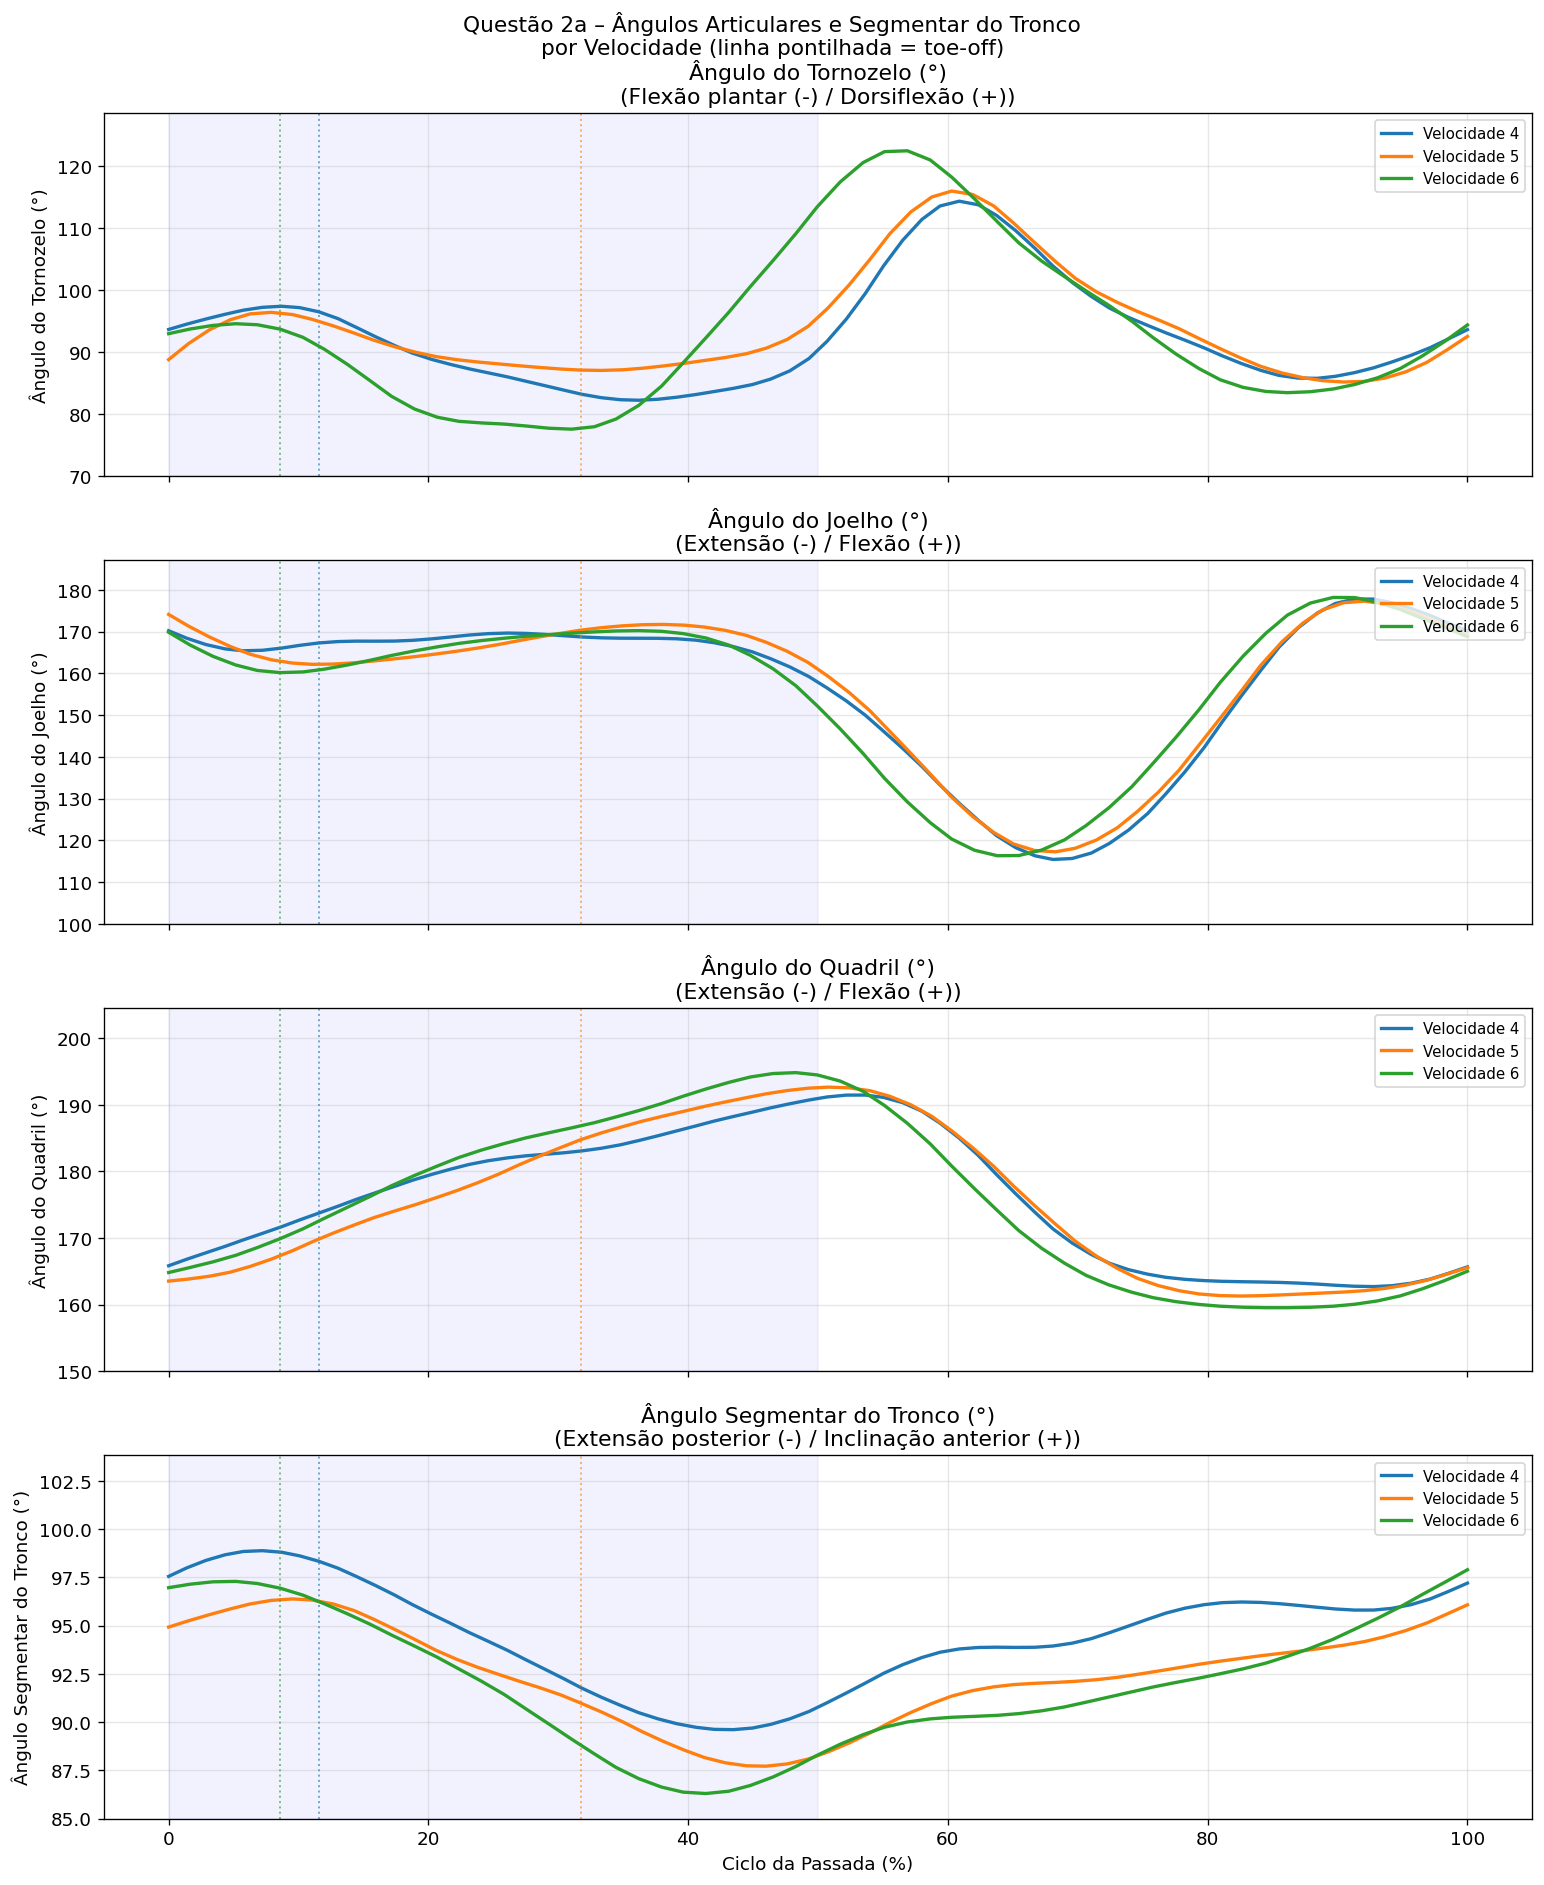

In [40]:
# ---------------------------------------------------------------
# Questão 2a – Gráficos dos ângulos por articulação/segmento
# ---------------------------------------------------------------

variaveis = [
    ('ang_tornozelo', 'Ângulo do Tornozelo (°)', 'Flexão plantar (-) / Dorsiflexão (+)'),
    ('ang_joelho',    'Ângulo do Joelho (°)',     'Extensão (-) / Flexão (+)'),
    ('ang_quadril',   'Ângulo do Quadril (°)',    'Extensão (-) / Flexão (+)'),
    ('theta_tronco',  'Ângulo Segmentar do Tronco (°)', 'Extensão posterior (-) / Inclinação anterior (+)')
]

fig, axes = plt.subplots(4, 1, figsize=(13, 16), sharex=True)

for ax, (var, ylabel, interpretation) in zip(axes, variaveis):
    for key in ['v4', 'v5', 'v6']:
        p = passadas[key]
        if p is None:
            continue
        # Filtra ângulo para suavizar
        t_arr = p['t'].values
        dt = np.mean(np.diff(t_arr))
        fs = 1 / dt
        ang_f = butter_lowpass(p[var].values, cutoff=6, fs=fs)

        ax.plot(p['t_norm'], ang_f,
                label=labels_vel[key], color=cores_vel[key], lw=2)

        # Marca toe-off
        to_norm = p['t_to_norm'].iloc[0]
        if not np.isnan(to_norm):
            ax.axvline(to_norm, color=cores_vel[key],
                       linestyle=':', alpha=0.6, lw=1.2)

    ax.axhline(0, color='k', linestyle='-', lw=0.8, alpha=0.5)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel}\n({interpretation})')
    ax.legend(loc='upper right', fontsize=9)
    # Shading fase de apoio (aprox até 40-60% dependendo da velocidade)
    ax.axvspan(0, 50, alpha=0.05, color='blue', label='Fase de apoio (aprox.)')
    
    if var == 'ang_tornozelo':
        ax.set_ylim(70, None)

    elif var == 'ang_joelho':
        ax.set_ylim(100, None)

    elif var == 'ang_quadril':
        ax.set_ylim(150, None)

    elif var == 'theta_tronco':
        ax.set_ylim(85, None)


axes[-1].set_xlabel('Ciclo da Passada (%)')
plt.suptitle('Questão 2a – Ângulos Articulares e Segmentar do Tronco\npor Velocidade (linha pontilhada = toe-off)', fontsize=13)
plt.tight_layout()
plt.show()

In [41]:
# ---------------------------------------------------------------
# Questão 2b e 2c – Interpretação (impressa para relatório)
# ---------------------------------------------------------------
print("""
=== Questão 2b – Interpretação dos Gráficos ===

TORNOZELO:
  - No heel strike, está em posição neutra.
  - Na fase de apoio, ocorre dorsiflexão progressiva.
  - No push-off, há flexão plantar para impulsão.
  - Na fase de balanço, retorna à dorsiflexão.

JOELHO:
  - No heel strike, está próximo da extensão completa.
  - No apoio, flexiona para absorção de impacto.
  - No balanço, flexiona intensamente para liberação do pé.

QUADRIL:
  - No heel strike, está flexionado (membro à frente).
  - Durante o apoio, estende progressivamente.
  - No balanço, flexiona novamente para avançar o membro.

TRONCO:
  - Mantém-se relativamente estável ao longo do ciclo.
  - Pode apresentar leve inclinação anterior em velocidades maiores.

=== Questão 2c – Efeito da Velocidade ===
  - A amplitude dos ângulos articulares aumenta com a velocidade.
  - O joelho apresenta maior pico de flexão no balanço.
  - O tornozelo apresenta maior flexão plantar no push-off.
  - A fase de apoio ocupa menor percentual do ciclo.
""")


=== Questão 2b – Interpretação dos Gráficos ===

TORNOZELO:
  - No heel strike, está em posição neutra.
  - Na fase de apoio, ocorre dorsiflexão progressiva.
  - No push-off, há flexão plantar para impulsão.
  - Na fase de balanço, retorna à dorsiflexão.

JOELHO:
  - No heel strike, está próximo da extensão completa.
  - No apoio, flexiona para absorção de impacto.
  - No balanço, flexiona intensamente para liberação do pé.

QUADRIL:
  - No heel strike, está flexionado (membro à frente).
  - Durante o apoio, estende progressivamente.
  - No balanço, flexiona novamente para avançar o membro.

TRONCO:
  - Mantém-se relativamente estável ao longo do ciclo.
  - Pode apresentar leve inclinação anterior em velocidades maiores.

=== Questão 2c – Efeito da Velocidade ===
  - A amplitude dos ângulos articulares aumenta com a velocidade.
  - O joelho apresenta maior pico de flexão no balanço.
  - O tornozelo apresenta maior flexão plantar no push-off.
  - A fase de apoio ocupa menor percentual 

---
## Questão 3 – Velocidade do Centro de Massa do Membro Inferior

### Modelo Antropométrico

O centro de massa do membro inferior é calculado como a soma ponderada dos centros de massa de cada segmento (De Leva, 1996):

| Segmento | Massa (% corp.) | CoM proximal (%) | Proximal | Distal |
|----------|----------------|-----------------|----------|--------|
| Coxa     | 10,0%          | 40,95%          | Trocânter | Epicôndilo |
| Perna    | 4,65%          | 40,49%          | Epicôndilo | Maléolo |
| Pé       | 1,45%          | 40,14%          | Calcâneo | 5º Metatarso |

*(Valores para mulheres, De Leva 1996)*

In [42]:
# ---------------------------------------------------------------
# Parâmetros antropométricos (Zatsiorsky & Seluyanov, 1983 
# Fração de massa relativa ao corpo total
# ---------------------------------------------------------------
m_coxa  = 0.1478  # 14,78%
m_perna = 0.0481  # 4,81%
m_pe    = 0.0129  # 1,29%
m_total = m_coxa + m_perna + m_pe

# Fração do CoM a partir do ponto proximal
com_coxa  = 0.4095   # T→E
com_perna = 0.4459   # E→M
com_pe    = 0.4014   # C→5Mt


def compute_com_lower_limb(df):
    """
    Calcula a posição do centro de massa do membro inferior (modelo De Leva, 1996).
    """
    # CoM de cada segmento
    com_coxa_x  = df['Tx'] + com_coxa  * (df['Ex']  - df['Tx'])
    com_coxa_y  = df['Ty'] + com_coxa  * (df['Ey']  - df['Ty'])

    com_perna_x = df['Ex'] + com_perna * (df['Mx']  - df['Ex'])
    com_perna_y = df['Ey'] + com_perna * (df['My']  - df['Ey'])

    com_pe_x    = df['Cx'] + com_pe    * (df['MTx'] - df['Cx'])
    com_pe_y    = df['Cy'] + com_pe    * (df['MTy'] - df['Cy'])

    # CoM ponderado do membro inferior
    com_x = (m_coxa * com_coxa_x + m_perna * com_perna_x + m_pe * com_pe_x) / m_total
    com_y = (m_coxa * com_coxa_y + m_perna * com_perna_y + m_pe * com_pe_y) / m_total

    return com_x.values, com_y.values


def compute_velocity(t, x, y, fs_out=None):
    """
    Calcula as componentes horizontal e vertical da velocidade
    usando diferenças finitas centrais.
    """
    # Derivada numérica (diferenças centrais)
    vx = np.gradient(x, t)
    vy = np.gradient(y, t)
    return vx, vy


# Calcula CoM e velocidade para cada velocidade
com_data = {}
for key, df in velocidades.items():
    cx, cy = compute_com_lower_limb(df)
    t = df['t'].values
    dt = np.mean(np.diff(t))
    fs = 1/dt

    # Suaviza posição antes de derivar
    cx_f = butter_lowpass(cx, cutoff=6, fs=fs)
    cy_f = butter_lowpass(cy, cutoff=6, fs=fs)

    vx, vy = compute_velocity(t, cx_f, cy_f)

    com_data[key] = {'t': t, 'cx': cx_f, 'cy': cy_f, 'vx': vx, 'vy': vy}


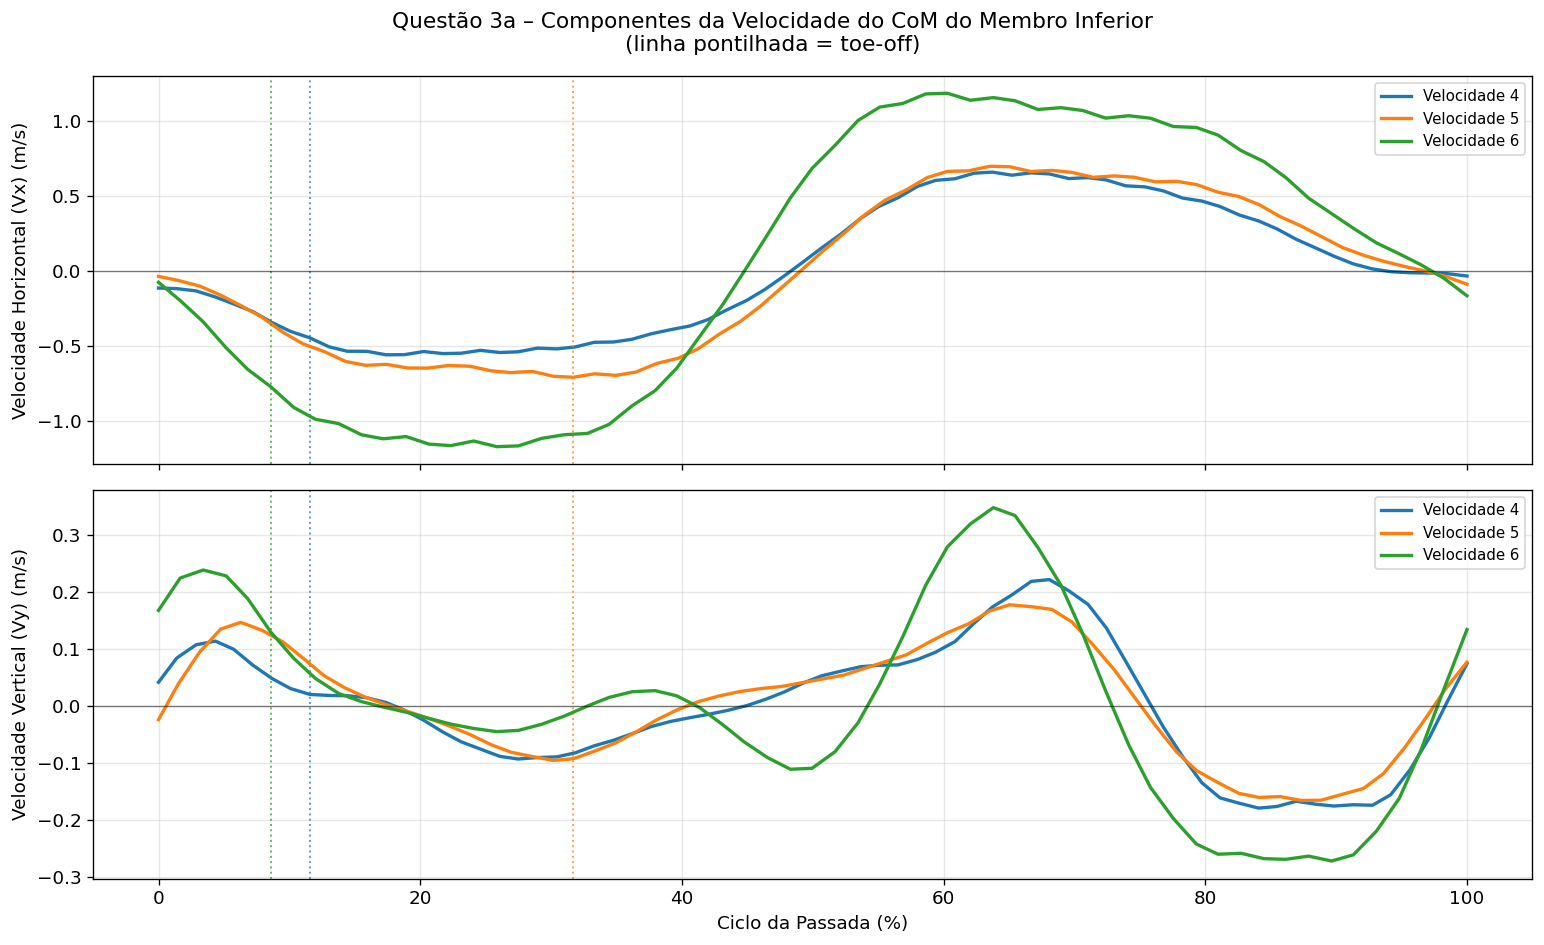

In [43]:
# ---------------------------------------------------------------
# Questão 3a – Gráfico das componentes de velocidade do CoM
# (para uma passada completa, as 3 velocidades no mesmo eixo)
# ---------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for key in ['v4', 'v5', 'v6']:
    ev  = eventos[key]
    d   = com_data[key]
    hs  = ev['hs']

    if len(hs) < 2:
        continue

    t_start = hs[0]
    t_end   = hs[1]
    mask    = (d['t'] >= t_start) & (d['t'] <= t_end)
    t_norm  = (d['t'][mask] - t_start) / (t_end - t_start) * 100

    axes[0].plot(t_norm, d['vx'][mask], label=labels_vel[key],
                 color=cores_vel[key], lw=2)
    axes[1].plot(t_norm, d['vy'][mask], label=labels_vel[key],
                 color=cores_vel[key], lw=2)

    # Marca toe-off
    to_in = ev['to'][(ev['to'] >= t_start) & (ev['to'] <= t_end)]
    if len(to_in) > 0:
        to_norm_val = (to_in[0] - t_start) / (t_end - t_start) * 100
        axes[0].axvline(to_norm_val, color=cores_vel[key], ls=':', lw=1.2, alpha=0.7)
        axes[1].axvline(to_norm_val, color=cores_vel[key], ls=':', lw=1.2, alpha=0.7)

for ax, comp in zip(axes, ['Horizontal (Vx)', 'Vertical (Vy)']):
    ax.axhline(0, color='k', lw=0.8, alpha=0.5)
    ax.set_ylabel(f'Velocidade {comp} (m/s)')
    ax.legend(loc='upper right', fontsize=9)

axes[1].set_xlabel('Ciclo da Passada (%)')
plt.suptitle('Questão 3a – Componentes da Velocidade do CoM do Membro Inferior\n(linha pontilhada = toe-off)', fontsize=13)
plt.tight_layout()
plt.show()

In [44]:
# ---------------------------------------------------------------
# Questão 3b – Velocidade no instante do toe-off
# ---------------------------------------------------------------
print("=== Questão 3b – Velocidade do CoM no Toe-off ===")
print(f"{'Velocidade':<15} {'Vx toe-off (m/s)':>18} {'Vy toe-off (m/s)':>18} {'|V| (m/s)':>12} {'Ângulo (°)':>12}")
print("-" * 80)

for key in ['v4', 'v5', 'v6']:
    ev = eventos[key]
    d  = com_data[key]
    hs = ev['hs']
    to = ev['to']

    if len(hs) < 2 or len(to) == 0:
        continue

    t_start = hs[0]
    t_end   = hs[1]
    to_in   = to[(to >= t_start) & (to <= t_end)]

    if len(to_in) == 0:
        continue

    t_to = to_in[0]

    # Interpola velocidade no instante exato do toe-off
    f_vx = interp1d(d['t'], d['vx'], kind='linear', fill_value='extrapolate')
    f_vy = interp1d(d['t'], d['vy'], kind='linear', fill_value='extrapolate')

    vx_to = float(f_vx(t_to))
    vy_to = float(f_vy(t_to))
    v_mag = np.sqrt(vx_to**2 + vy_to**2)
    ang   = np.degrees(np.arctan2(vy_to, vx_to))

    print(f"{labels_vel[key]:<15} {vx_to:>18.4f} {vy_to:>18.4f} {v_mag:>12.4f} {ang:>12.2f}")

print("""
Interpretação:
  - Vx positivo indica que o membro está se movendo para frente.
  - Vy positivo indica que o membro está subindo (início da fase de balanço).
  - O ângulo com a horizontal indica a 'trajetória de lançamento' do membro inferior.
""")

=== Questão 3b – Velocidade do CoM no Toe-off ===
Velocidade        Vx toe-off (m/s)   Vy toe-off (m/s)    |V| (m/s)   Ângulo (°)
--------------------------------------------------------------------------------
Velocidade 4               -0.4478             0.0203       0.4482       177.41
Velocidade 5               -0.7107            -0.0924       0.7167      -172.59
Velocidade 6               -0.7742             0.1294       0.7850       170.51

Interpretação:
  - Vx positivo indica que o membro está se movendo para frente.
  - Vy positivo indica que o membro está subindo (início da fase de balanço).
  - O ângulo com a horizontal indica a 'trajetória de lançamento' do membro inferior.



In [45]:
# ---------------------------------------------------------------
# Questão 3c – Discussão do efeito da velocidade
# ---------------------------------------------------------------
print("""
=== Questão 3c – Efeito da Velocidade sobre a Velocidade do CoM no Toe-off ===

Com o aumento da velocidade de corrida:

1. A componente horizontal (Vx) da velocidade no toe-off aumenta, refletindo que
   o membro inferior precisa avançar mais rapidamente para acompanhar a maior
   velocidade de deslocamento.

2. A componente vertical (Vy) também tende a aumentar em magnitude, indicando
   que o membro é projetado com maior força para cima no início da fase de balanço,
   o que é necessário para garantir maior tempo de balanço e maior comprimento da
   passada.

3. O módulo do vetor velocidade aumenta com a velocidade de corrida, o que é
   esperado, pois a maior velocidade de locomoção requer maior velocidade dos
   segmentos corporais.

4. O ângulo de 'lançamento' pode variar com a velocidade, refletindo a estratégia
   biomecânica adotada: em velocidades maiores, o ângulo tende a ser mais horizontal,
   priorizando o avanço em detrimento da elevação.

5. Esses resultados são consistentes com a literatura, que descreve que corredores
   mais rápidos apresentam maior excursão e velocidade dos membros inferiores,
   bem como maior comprimento de passada.
""")


=== Questão 3c – Efeito da Velocidade sobre a Velocidade do CoM no Toe-off ===

Com o aumento da velocidade de corrida:

1. A componente horizontal (Vx) da velocidade no toe-off aumenta, refletindo que
   o membro inferior precisa avançar mais rapidamente para acompanhar a maior
   velocidade de deslocamento.

2. A componente vertical (Vy) também tende a aumentar em magnitude, indicando
   que o membro é projetado com maior força para cima no início da fase de balanço,
   o que é necessário para garantir maior tempo de balanço e maior comprimento da
   passada.

3. O módulo do vetor velocidade aumenta com a velocidade de corrida, o que é
   esperado, pois a maior velocidade de locomoção requer maior velocidade dos
   segmentos corporais.

4. O ângulo de 'lançamento' pode variar com a velocidade, refletindo a estratégia
   biomecânica adotada: em velocidades maiores, o ângulo tende a ser mais horizontal,
   priorizando o avanço em detrimento da elevação.

5. Esses resultados são consis

### Resposta da 5 individual Atualizada

- Helena

- Joao 

- Júlia - Após realizar o cálculo dos ângulos de duas maneiras no papel, foi possível analisar de maneira completa os gráficos obtidos e os valores dos gráficos estão coincidindo com os valores obtidos na atividade individual. Ao calcular com coordenadas polares, cheguei nos valores de: 154,05 graus para o quadril, 147,53 para o joelho e 84,43 para o tornozelo e ao olhar os gráficos perto da porcentagem de 4,5% (que é a do meu tempo), existe sim um desvio de valores. Mas isso pode ter sido causado por diversos fatores, como variações nos movimentos, variações nas velocidades, tendo em mente que a bel estava caminhando e o exercicio individual era de uma mulher correndo. Além disso, podem ter interferências da qualidade da gravação em ambos os videos e diferenca na localização dos marcadores, visto que algumas marcações foram feitos manualmente. --> Favor desconsiderar a resposta da 5 do papel entregue, havia respondido com os gráficos incorretos. No entanto, agora foram corrigidos. Obrigada :) 

- Mari

- Sabryna 

- Fellipe Godoy

- Giovanna